# MAE 3127 - Fall 2025
# Laboratory: Impact of a jet Experiment
    
### Instructor and code author: Prof. Kartik Bulusu [MAE] 
    
#### Graduate Teaching Assistants: Bengisu Sisik, Swastika Bera [MAE] 
#### Undergraduate Teaching Assistant: Salman NIazi [MAE]
#### Learning Assistant: Lucy Truemper [CEE]


**Must-do:** 
- **A sample data set (`SampleData_ImpactOfJet.xlsx`) is provided to you.** 
- You are stongly encouraged to use this Jupyter notebook to practice with the sample data set. 
- Read through all comments; sometimes they are cryptic and sometimes funny! They are useful nonetheless.
- When are sure about how to run the program you can then try it on **your** experimental data. 

**Caveat:**   
- **Do not change the headers, column names or table names in the file, `SampleData_ImpactOfJet.xlsx`.**
- You can remove the sample data to include your data generated from the experiment when you are ready.

## Let's start by importing our favorite friends as always going forward in this class: **numpy**, **matplotlib**, and **pandas**

In [1]:
import numpy as np
from numpy import polyfit
from matplotlib import pyplot as plt
import pandas as pd

Before we get started with pandas, we are going to introduce a function called `help()` which will provide some information about functions we are working with!

In [2]:
#Here we ask python to tell us about the np.array function, but this works with everything!

help(np.array)

Help on built-in function array in module numpy:

array(...)
    array(object, dtype=None, *, copy=True, order='K', subok=False, ndmin=0,
          like=None)
    
    Create an array.
    
    Parameters
    ----------
    object : array_like
        An array, any object exposing the array interface, an object whose
        __array__ method returns an array, or any (nested) sequence.
    dtype : data-type, optional
        The desired data-type for the array.  If not given, then the type will
        be determined as the minimum type required to hold the objects in the
        sequence.
    copy : bool, optional
        If true (default), then the object is copied.  Otherwise, a copy will
        only be made if __array__ returns a copy, if obj is a nested sequence,
        or if a copy is needed to satisfy any of the other requirements
        (`dtype`, `order`, etc.).
    order : {'K', 'A', 'C', 'F'}, optional
        Specify the memory layout of the array. If object is not an array

## Start playing with `pandas` library to get all the data from the  excel spreadsheet into python.

### Jargon: `dataframe` 

### Pandas is a library to work with dataframe objects. Dataframes are a way to represent data in rows and columns, much like a matrix!! 

### A little vocab to get us started. I promise it won't be much! 
- The **columns** of a dataframe are called the **columns**
- The **rows** of the dataframe are called the **index** 

See that wasn't too bad :)

Last week we discussed importing data from a csv file into a pandas dataframe. We are going to bring that back and do a whole lot more with it this week! We have provided a `SampleData_ImpactOfJet.xlsx` file in this week's content for this demonstration! 


#### Here are the steps!
1. Locate place the file titled `SampleData_ImpactOfJet.xlsx` in the same folder as this jupyter notebook file

3. `Copy Path or Filenmake to Clipboard`; you may have to append `.xlsx` to the file name.

4. Establish a `filename` variable in a code cell that is an empty string using `filename = ''` as show in the cell below

5. Inside the quotes paste the path using `Ctrl+V` or `Cmd+V` on your keyboard

6. You should now have something like this: `filename = 'SampleData_ImpactOfJet.xlsx'`

7. Finally, use `data = pd.ExcelFile(filename)` to save your file into a pandas dataframe!


Before I started writing this code for your class I was playig with files from the datasets in [vega_datasets](https://vega.github.io/vega-datasets/), if you are curious.

In [3]:
filename = 'SampleData_ImpactOfJet.xlsx'
data = pd.ExcelFile(filename)
df1 = pd.read_excel(data, 'Beta = 90 degrees')
df2 = pd.read_excel(data, 'Beta = 120 degrees')
df3 = pd.read_excel(data, 'Beta = 180 degrees')

## Showing Dataframes
To show dataframes, we have a couple of options! First we can use what we did last week using the `display(df)` function which operates similarly to `print()`. We can also use `df.head()` and `df.tail()` which will just show parts of the frame. The `.head(n)` shows the first n lines of the frame, and the `.tail(m)` shows the last m lines of the frame

Let's try these out!

## Data related to 'Beta = 90 degrees'

In [4]:
display(df1) 
# Before sorting in ascending order

df1 = df1.sort_values(by=['Q (Ls^-1)'])
# After sorting all columns with respect to the flowrate column (Q, Ls^-1) in ascending order
print(df1)

,Q (Ls^-1),Distance y (mm),m_dot (kg s^-1),u (ms^-1),u0 (ms^-1),m_dot x u0 (kg m s^-2),"Experimental force, F (N)","Theoretical force, F (N)"
0,0.596,109,0.596,7.588490,7.543108,4.495692,4.27716,4.495692
1,0.578,98,0.578,7.359307,7.312503,4.226627,3.84552,4.226627
2,0.563,93,0.563,7.168322,7.120263,4.008708,3.64932,4.008708
3,0.546,89,0.546,6.951872,6.902305,3.768659,3.49236,3.768659
4,0.533,85,0.533,6.786351,6.735567,3.590057,3.33540,3.590057
5,0.512,80,0.512,6.518971,6.466087,3.310637,3.13920,3.310637


   Q (Ls^-1)  Distance y (mm)  m_dot (kg s^-1)  u (ms^-1)  u0 (ms^-1)  \
5      0.512               80            0.512   6.518971    6.466087   
4      0.533               85            0.533   6.786351    6.735567   
3      0.546               89            0.546   6.951872    6.902305   
2      0.563               93            0.563   7.168322    7.120263   
1      0.578               98            0.578   7.359307    7.312503   
0      0.596              109            0.596   7.588490    7.543108   

   m_dot x u0 (kg m s^-2)  Experimental force, F (N)  Theoretical force, F (N)  
5                3.310637                    3.13920                  3.310637  
4                3.590057                    3.33540                  3.590057  
3                3.768659                    3.49236                  3.768659  
2                4.008708                    3.64932                  4.008708  
1                4.226627                    3.84552                  4.226627  
0 

### Getting the head and tail of dataframe (`df1`), literally!

In [5]:
df1.head(4)

,Q (Ls^-1),Distance y (mm),m_dot (kg s^-1),u (ms^-1),u0 (ms^-1),m_dot x u0 (kg m s^-2),"Experimental force, F (N)","Theoretical force, F (N)"
5,0.512,80,0.512,6.518971,6.466087,3.310637,3.13920,3.310637
4,0.533,85,0.533,6.786351,6.735567,3.590057,3.33540,3.590057
3,0.546,89,0.546,6.951872,6.902305,3.768659,3.49236,3.768659
2,0.563,93,0.563,7.168322,7.120263,4.008708,3.64932,4.008708


In [6]:
df1.tail(4)

,Q (Ls^-1),Distance y (mm),m_dot (kg s^-1),u (ms^-1),u0 (ms^-1),m_dot x u0 (kg m s^-2),"Experimental force, F (N)","Theoretical force, F (N)"
3,0.546,89,0.546,6.951872,6.902305,3.768659,3.49236,3.768659
2,0.563,93,0.563,7.168322,7.120263,4.008708,3.64932,4.008708
1,0.578,98,0.578,7.359307,7.312503,4.226627,3.84552,4.226627
0,0.596,109,0.596,7.588490,7.543108,4.495692,4.27716,4.495692


In [7]:
#Just to showcase it, let's use help(df.tail)
help(df1.tail)

Help on method tail in module pandas.core.generic:

tail(n: 'int' = 5) -> 'NDFrameT' method of pandas.core.frame.DataFrame instance
    Return the last `n` rows.
    
    This function returns last `n` rows from the object based on
    position. It is useful for quickly verifying data, for example,
    after sorting or appending rows.
    
    For negative values of `n`, this function returns all rows except
    the first `n` rows, equivalent to ``df[n:]``.
    
    Parameters
    ----------
    n : int, default 5
        Number of rows to select.
    
    Returns
    -------
    type of caller
        The last `n` rows of the caller object.
    
    See Also
    --------
    DataFrame.head : The first `n` rows of the caller object.
    
    Examples
    --------
    >>> df = pd.DataFrame({'animal': ['alligator', 'bee', 'falcon', 'lion',
    ...                    'monkey', 'parrot', 'shark', 'whale', 'zebra']})
    >>> df
          animal
    0  alligator
    1        bee
    2     fa

## Data related to 'Beta = 120 degrees'

In [8]:
display(df2)
# Before sorting in ascending order

df2 = df2.sort_values(by=['Q (Ls^-1)'])
# After sorting all columns with respect to the flowrate column (Q, Ls^-1) in ascending order
print(df2)

,Q (Ls^-1),Distance y (mm),m_dot (kg s^-1),u (ms^-1),u0 (ms^-1),m_dot x u0 (kg m s^-2),"Experimental force, F (N)","Theoretical force, F (N)"
0,0.2600,30,0.2600,3.310415,3.205019,0.833305,1.17720,1.249957
1,0.3125,55,0.3125,3.978864,3.891614,1.216129,2.15820,1.824194
2,0.4170,90,0.4170,5.309396,5.244329,2.186885,3.53160,3.280328
3,0.4630,127,0.4630,5.895085,5.836551,2.702323,4.98348,4.053485
4,0.5000,145,0.5000,6.366183,6.312019,3.156010,5.68980,4.734014
5,0.6060,200,0.6060,7.715814,7.671185,4.648738,7.84800,6.973107


   Q (Ls^-1)  Distance y (mm)  m_dot (kg s^-1)  u (ms^-1)  u0 (ms^-1)  \
0     0.2600               30           0.2600   3.310415    3.205019   
1     0.3125               55           0.3125   3.978864    3.891614   
2     0.4170               90           0.4170   5.309396    5.244329   
3     0.4630              127           0.4630   5.895085    5.836551   
4     0.5000              145           0.5000   6.366183    6.312019   
5     0.6060              200           0.6060   7.715814    7.671185   

   m_dot x u0 (kg m s^-2)  Experimental force, F (N)  Theoretical force, F (N)  
0                0.833305                    1.17720                  1.249957  
1                1.216129                    2.15820                  1.824194  
2                2.186885                    3.53160                  3.280328  
3                2.702323                    4.98348                  4.053485  
4                3.156010                    5.68980                  4.734014  
5 

## Data related to 'Beta = 180 degrees'

In [9]:
display(df3)
# Before sorting in ascending order

df3 = df3.sort_values(by=['Q (Ls^-1)'])
# After sorting all columns with respect to the flowrate column (Q, Ls^-1) in ascending order
print(df3)

,Q (Ls^-1),Distance y (mm),m_dot (kg s^-1),u (ms^-1),u0 (ms^-1),m_dot x u0 (kg m s^-2),"Experimental force, F (N)","Theoretical force, F (N)"
0,0.4630,127,0.4630,5.895085,5.836551,2.702323,4.98348,4.053485
1,0.3125,55,0.3125,3.978864,3.891614,1.216129,2.15820,1.824194
2,0.5000,145,0.5000,6.366183,6.312019,3.156010,5.68980,4.734014
3,0.6060,200,0.6060,7.715814,7.671185,4.648738,7.84800,6.973107
4,0.2600,30,0.2600,3.310415,3.205019,0.833305,1.17720,1.249957
5,0.4170,90,0.4170,5.309396,5.244329,2.186885,3.53160,3.280328


   Q (Ls^-1)  Distance y (mm)  m_dot (kg s^-1)  u (ms^-1)  u0 (ms^-1)  \
4     0.2600               30           0.2600   3.310415    3.205019   
1     0.3125               55           0.3125   3.978864    3.891614   
5     0.4170               90           0.4170   5.309396    5.244329   
0     0.4630              127           0.4630   5.895085    5.836551   
2     0.5000              145           0.5000   6.366183    6.312019   
3     0.6060              200           0.6060   7.715814    7.671185   

   m_dot x u0 (kg m s^-2)  Experimental force, F (N)  Theoretical force, F (N)  
4                0.833305                    1.17720                  1.249957  
1                1.216129                    2.15820                  1.824194  
5                2.186885                    3.53160                  3.280328  
0                2.702323                    4.98348                  4.053485  
2                3.156010                    5.68980                  4.734014  
3 

### Note: There is not data in the table, 'Beta = 180 degrees' in file, `SampleData_ImpactOfJet.xlsx`. 
**It was deliberately left with only the column labels and headers empty.**
**That's why there is not data showing up.**
**You get the idea!

## Dataframe Shape

An **m** x **n** matrix has **m** rows and **n** columns. A dataframe also has rows and columns! Let's get the shape of the dataframe using `df1.shape`

`df1.shape` will return the `(number_of_rows, number_of_columns)`

In [10]:
df1.shape
# Note: Table-related to the dataframe df1 needs to be filled with your experimental data. 
# It has been filled with sample data in the file.

(6, 8)

In [11]:
df2.shape 
# Note: Table-related to the dataframe df2 needs to be filled with your experimental data. 
# It has been filled with sample data in the file.

(6, 8)

In [12]:
df3.shape
# Note: Table-related to the dataframe df3 needs to be filled with your experimental data. 
# It has been deliberately left blank in the sample data file.

(6, 8)

## Accessing Data within Frames

## Let's start with accessing data in the dataframe, `df1`.

Using the `df1.iloc['Row', 'Column']` function we can locate certain data. 

Last week we used this for plotting. We will get to that in a second. Let's pull out all the data starting with `row-index 1` and `column-index 1` in the dataframe `df1`.

In [13]:
Momentum_rate_90 = df1.iloc[:,5]

In [14]:
Momentum_rate_90 = list(Momentum_rate_90)

# A little bit Python wizardry happened in this cell.
# The date saved in the variable, `Momemtum_rate_90` was converted into a `list` data type to avoid future pain.
# While you are expected to follow along to get to the beautiful data plot presented later, 
# you can do your own research exploring various Python data types such as int, float, list, arrays, dictionaries etc.

In [15]:
Momentum_rate_90

[3.3106367316186254,
 3.5900570440590207,
 3.7686587369700386,
 4.008707804234739,
 4.226626919107985,
 4.495692419023809]

In [16]:
Experimental_force_90 = df1.iloc[:,6]

In [17]:
Experimental_force_90 = list(Experimental_force_90)

# A little bit Python wizardry happened in this cell.
# The date saved in the variable, `Experimental_force_90` was converted into a `list` data type to avoid future pain.
# While you are expected to follow along to get to the beautiful data plot presented later, 
# you can do your own research exploring various Python data types such as int, float, list, arrays, dictionaries etc.

In [18]:
Experimental_force_90

[3.1392, 3.3354, 3.49236, 3.6493200000000003, 3.84552, 4.27716]

In [19]:
Theoretical_force_90 = df1.iloc[:,7]

In [20]:
Theoretical_force_90 = list(Theoretical_force_90)

# A little bit Python wizardry happened in this cell.
# The date saved in the variable, `Theoretical_force_90` was converted into a `list` data type to avoid future pain.
# While you are expected to follow along to get to the beautiful data plot presented later, 
# you can do your own research exploring various Python data types such as int, float, list, arrays, dictionaries etc.

In [21]:
Theoretical_force_90

[3.310636731618625,
 3.5900570440590203,
 3.768658736970038,
 4.008707804234738,
 4.226626919107984,
 4.495692419023808]

## Matplotlib Pyplot Figures and Subplots for the dataframe, `df1`
## Also .. First-degree polynomial fit, fancy way of saying linear-fit.

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. Matplotlib makes easy things easy and hard things possible. 

Source: https://matplotlib.org

A figure is just a place for our plots to exist. A figure can have multiple **subplots** which are arranged like a matrix in rows and columns. Each subplot is called an axis. 

In the cell that follows, we also will use `np.polyfit()` to `np.poly1d()` to create a first-degree best fit line.

Let's play around with the subplots feature a little bit.

To create a set of axes, use the function:

`fig, axs = plt.subplots(num_of_rows, number_of_columns, figsize=(width, height))`

Let's break this down a little at a time. 

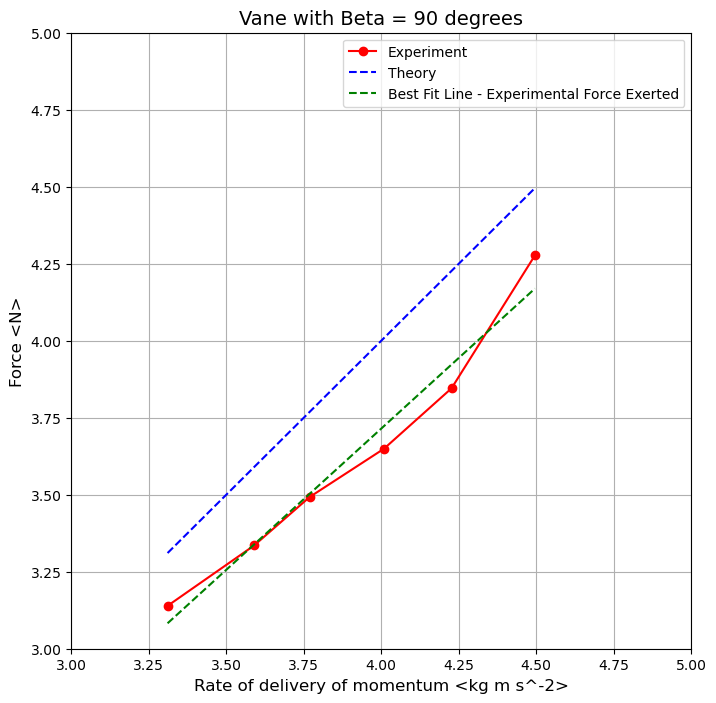

In [22]:
#set up our single subplot!
fig, ax = plt.subplots(figsize=(8,8))

#let's establish the x-axis with the variable "Momentum_rate"

#And establish our y-axis values with the following variables:
#Experimental_force
#Theoretical_force

# red dashes, blue dots and green triangles
ax.plot(Momentum_rate_90, Experimental_force_90, color='r', marker='o', label='Experiment')
ax.plot(Momentum_rate_90, Theoretical_force_90, color='b', linestyle='--', label='Theory') 

#plot first-degree least-squares fit lines for Experimental Force Exerted for Table 3
C_90 = np.polyfit(Momentum_rate_90, Experimental_force_90, 1) #define coefficients for slope and y-intercept

# Get the slope and intercept of the line
slope_90 = C_90[0]
#print(slope_90)
intercept_90 = C_90[1]
#print(intercept_90)

f_linear_90 = np.poly1d(C_90) #create function for best fit line using slope and y-intercept
bestfit_line = f_linear_90(Momentum_rate_90)

#plot the best fit line for the experimental values using a dashed red line
ax.plot(Momentum_rate_90, bestfit_line, color='g', linestyle='--', label='Best Fit Line - Experimental Force Exerted')


#and lets get a little fancy an add some labeling
ax.set_xlabel('Rate of delivery of momentum <kg m s^-2>', fontsize=12)
ax.set_ylabel('Force <N>', fontsize=12)

#and maybe a title for our plot
ax.set_title('Vane with Beta = 90 degrees', fontsize=14)

#ax.axis([x1, x2, y1, y2]) limits the view we want to see
ax.axis([3, 5, 3, 5])

#ax.grid() adds a grid to the plot
ax.grid()

#ax.lengend() adds a legend (and finally a semi-colon to eliminate the default printing)
ax.legend();

## Save the above plot as a png-file, for the dataframe, `df1`

Note that `fig` is the variable assigned to the plot above. 
Review the cell with the plotting code.
The following line of code will save the above plot in the same working directory where the the jupyter notebook was saved. 

In [23]:
fig.savefig('Bulusu_Moss_Gajula_Consultants1.png')

## Let's now try accessing data in the dataframe, `df2`.

Using the `df2.iloc['Row', 'Column']` function we can locate certain data. 

Last week we used this for plotting. We will get to that in a second. Let's pull out all the data starting with `row-index 1` and `column-index 1` in the dataframe `df1`.

In [24]:
Momentum_rate_120 = df2.iloc[:,5]

In [25]:
Momentum_rate_120 = list(Momentum_rate_120)

# A little bit Python wizardry happened in this cell.
# The date saved in the variable, `Momemtum_rate_120` was converted into a `list` data type to avoid future pain.
# While you are expected to follow along to get to the beautiful data plot presented later, 
# you can do your own research exploring various Python data types such as int, float, list, arrays, dictionaries etc.

In [26]:
Momentum_rate_120

[0.8333049878310794,
 1.21612943031991,
 2.1868853672915844,
 2.7023232399019768,
 3.1560095021719508,
 4.64873811700808]

In [27]:
Experimental_force_120 = df2.iloc[:,6]

In [28]:
Experimental_force_120 = list(Experimental_force_120)

# A little bit Python wizardry happened in this cell.
# The date saved in the variable, `Experimental_force_120` was converted into a `list` data type to avoid future pain.
# While you are expected to follow along to get to the beautiful data plot presented later, 
# you can do your own research exploring various Python data types such as int, float, list, arrays, dictionaries etc.

In [29]:
Experimental_force_120

[1.1772, 2.1582000000000003, 3.5316000000000005, 4.98348, 5.6898, 7.848]

In [30]:
Theoretical_force_120 = df2.iloc[:,7]

In [31]:
Theoretical_force_120 = list(Theoretical_force_120)

# A little bit Python wizardry happened in this cell.
# The date saved in the variable, `Theoretical_force_120` was converted into a `list` data type to avoid future pain.
# While you are expected to follow along to get to the beautiful data plot presented later, 
# you can do your own research exploring various Python data types such as int, float, list, arrays, dictionaries etc.

In [32]:
Theoretical_force_120

[1.249957481746619,
 1.8241941454798647,
 3.280328050937376,
 4.053484859852965,
 4.734014253257925,
 6.973107175512119]

## Matplotlib Pyplot Figures and Subplots for the dataframe, `df2`
## Also .. First-degree polynomial fit, fancy way of saying linear-fit.

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. Matplotlib makes easy things easy and hard things possible. 

Source: https://matplotlib.org

A figure is just a place for our plots to exist. A figure can have multiple **subplots** which are arranged like a matrix in rows and columns. Each subplot is called an axis. 

In the cell that follows, we also will use `np.polyfit()` to `np.poly1d()` to create a first-degree best fit line.

Let's play around with the subplots feature a little bit.

To create a set of axes, use the function:

`fig, axs = plt.subplots(num_of_rows, number_of_columns, figsize=(width, height))`

Let's break this down a little at a time. 

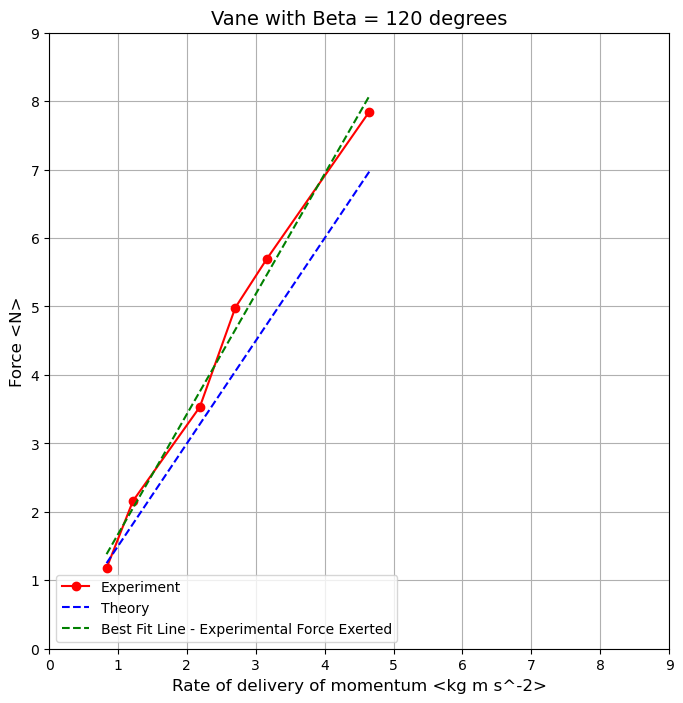

In [33]:
#set up our single subplot!
fig, ax = plt.subplots(figsize=(8,8))

#let's establish the x-axis with the variable "Momentum_rate"

#And establish our y-axis values with the following variables:
#Experimental_force
#Theoretical_force

# red dashes, blue dots and green triangles
ax.plot(Momentum_rate_120, Experimental_force_120, color='r', marker='o', label='Experiment')
ax.plot(Momentum_rate_120, Theoretical_force_120, color='b', linestyle='--', label='Theory') 

#plot first-degree least-squares fit lines for Experimental Force Exerted for Table 3
C_120 = np.polyfit(Momentum_rate_120, Experimental_force_120, 1) #define coefficients for slope and y-intercept

# Get the slope and intercept of the line
slope_120 = C_120[0]
#print(slope_120)
intercept_120 = C_120[1]
#print(intercept_120)

f_linear_120 = np.poly1d(C_120) #create function for best fit line using slope and y-intercept
bestfit_line = f_linear_120(Momentum_rate_120)

#plot the best fit line for the experimental values using a dashed red line
ax.plot(Momentum_rate_120, bestfit_line, color='g', linestyle='--', label='Best Fit Line - Experimental Force Exerted')


#and lets get a little fancy an add some labeling
ax.set_xlabel('Rate of delivery of momentum <kg m s^-2>', fontsize=12)
ax.set_ylabel('Force <N>', fontsize=12)

#and maybe a title for our plot
ax.set_title('Vane with Beta = 120 degrees', fontsize=14)

#ax.axis([x1, x2, y1, y2]) limits the view we want to see
ax.axis([0, 9, 0, 9])

#ax.grid() adds a grid to the plot
ax.grid()

#ax.lengend() adds a legend (and finally a semi-colon to eliminate the default printing)
ax.legend();

## Save the above plot as a png-file

Note that `fig` is the variable assigned to the plot above. 
Review the cell with the plotting code.
The following line of code will save the above plot in the same working directory where the the jupyter notebook was saved. 

In [34]:
fig.savefig('Bulusu_Moss_Gajula_Consultants2.png')

## Now that you learned how to run a python code that plots your experimental data

### You should have three tables of data gathered.
### You can start by adding data in the dataframe `df3` by modified the file, `SampleData_ImpactOfJet.xlsx`.

### You should 
1. Use the excel formatted template to input your own data gathered in the lab
2. Try adapting this Python code to plot your own data from lab. 
3. Make sure you include the excel spreadsheet file with you experimental data in the same folder as this code.

### Ultimately, you need to submit the following deliverables on Blackboard
1. Excel file with **your** experimental data
2. A working code that works with **your** experimental data and 
3. **Three plots in png-format** each showing the data from the geometries used in the experiment.
4. Scanned copy of the data written up in the handout provided to you in the lab.

### Only a working code that is written by you will be graded.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=928a4826-6d7d-44bd-b128-d6cd83127a49' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>